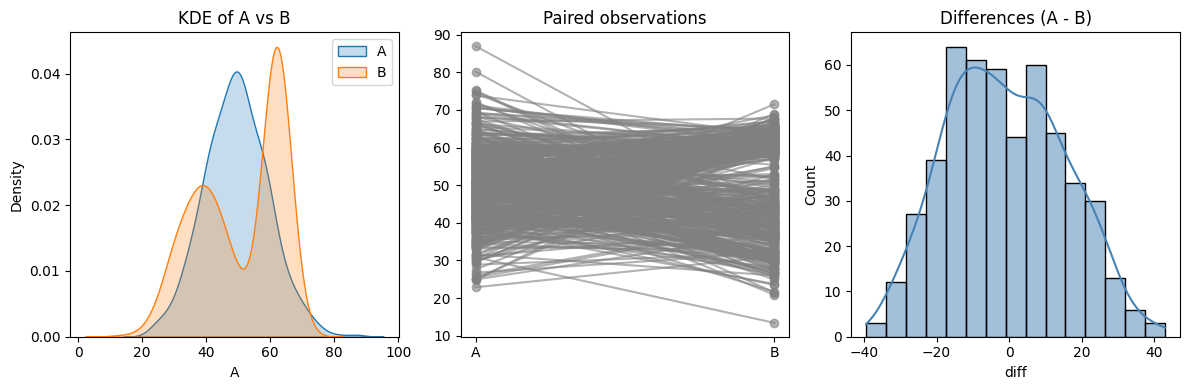

Plots saved to: /display_output/ab_comparison.png and /display_output/ab_comparison.svg
Method: paired t-test, n = 500, t = -1.3514, p = 0.1772, mean diff = -0.9765, 95% CI = [-2.396, 0.4432], Cohen's d = -0.060
No
Final answer written to: /display_output/final_result.txt


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon, shapiro, t

# Load data
df = pd.read_csv('input_data/data.csv')

# Ensure numeric and drop rows where A or B is missing
df[['A', 'B']] = df[['A', 'B']].apply(pd.to_numeric, errors='coerce')
paired = df.dropna(subset=['A', 'B']).copy()
n = len(paired)
if n < 2:
    raise ValueError("At least two paired observations are required after dropping missing values.")

# Difference
paired['diff'] = paired['A'] - paired['B']

# Normality test on differences
sh_stat, sh_p = shapiro(paired['diff'])
use_wilcoxon = (sh_p < 0.05) and (n < 30)

if not use_wilcoxon:
    # Paired t‑test
    t_stat, p_val = ttest_rel(paired['A'], paired['B'])
    md = paired['diff'].mean()
    sd = paired['diff'].std(ddof=1)
    cohens_d = md / sd if sd != 0 else np.nan
    se = sd / np.sqrt(n)
    ci_low = md - t.ppf(0.975, df=n-1) * se
    ci_high = md + t.ppf(0.975, df=n-1) * se
    method = 'paired t-test'
    test_stat_str = f"t = {t_stat:.4f}, p = {p_val:.4g}"
else:
    # Wilcoxon signed‑rank test
    w_stat, p_val = wilcoxon(paired['A'], paired['B'])
    md = paired['diff'].median()
    cohens_d = np.nan
    ci_low = ci_high = np.nan
    method = 'Wilcoxon signed-rank test'
    test_stat_str = f"W = {w_stat:.4f}, p = {p_val:.4g}"

# Decision
significant = p_val < 0.05
answer = "Yes" if significant else "No"

# ---------- Plots ----------
os.makedirs('/display_output', exist_ok=True)

plt.figure(figsize=(12, 4))

# KDE of A and B
plt.subplot(1, 3, 1)
sns.kdeplot(paired['A'], fill=True, label='A')
sns.kdeplot(paired['B'], fill=True, label='B')
plt.title('KDE of A vs B')
plt.legend()

# Paired scatter with lines
plt.subplot(1, 3, 2)
for i in range(n):
    plt.plot([0, 1], [paired['A'].iat[i], paired['B'].iat[i]],
             marker='o', color='gray', alpha=0.6)
plt.xticks([0, 1], ['A', 'B'])
plt.title('Paired observations')

# Histogram of differences
plt.subplot(1, 3, 3)
sns.histplot(paired['diff'], kde=True, bins=15, color='steelblue')
plt.title('Differences (A - B)')

plt.tight_layout()
plot_path_png = '/display_output/ab_comparison.png'
plot_path_svg = '/display_output/ab_comparison.svg'
plt.savefig(plot_path_png, dpi=150)
plt.savefig(plot_path_svg)
plt.show()
print(f'Plots saved to: {plot_path_png} and {plot_path_svg}')

# ---------- Reporting ----------
print(f"Method: {method}, n = {n}, {test_stat_str}, mean diff = {md:.4g}, "
      f"95% CI = [{ci_low:.4g}, {ci_high:.4g}], Cohen's d = {cohens_d:.3f}")

print(answer)

# Write final answer
output_path = '/display_output/final_result.txt'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
with open(output_path, 'w') as f:
    f.write(answer)
print(f'Final answer written to: {output_path}')
